# 매출 리포트

`src/data.py`, `src/metrics.py`에 있는 함수들을 불러와서
지역별 / 월별 / 월별x지역별 / 제품별 / 지역x제품 매출을
표와 그래프로 확인하는 노트북이다.

**이 노트북은 계산을 직접 하지 않는다.** 계산은 전부 `src` 폴더의 함수가 담당하고,
여기서는 그 결과를 불러와서 보여주고(표/그래프) 파일로 저장하는 일만 한다.

In [1]:
# os : 폴더가 없으면 새로 만들 때(makedirs) 사용한다.
# matplotlib.pyplot : 그래프를 그리기 위해 사용한다.
import os

import matplotlib.pyplot as plt

# src/data.py, src/metrics.py에 만들어둔 함수들을 가져온다.
# (이 노트북에서는 계산 로직을 새로 만들지 않고, 이미 만든 함수를 그대로 가져다 쓴다)
from src.data import add_month_column, add_quarter_column, load_sales
from src.metrics import (
    calc_monthly_region_pivot,
    calc_monthly_totals,
    calc_pareto_analysis,
    calc_product_totals,
    calc_quarterly_totals,
    calc_region_bestseller,
    calc_region_product_pivot,
    calc_region_totals,
)

# 그래프에서 한글이 깨지지 않도록 폰트 설정 (Windows 기본 한글 폰트)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = os.path.join("data", "sales.csv")
IMAGE_DIR = "images"
REPORT_DIR = "reports"

In [2]:
# 매출 CSV를 읽는다.
df = load_sales(DATA_PATH)

# 월별 분석에 필요한 '연월' 컬럼을 추가한 버전도 미리 만들어둔다.
df_month = add_month_column(df)

# 데이터가 잘 읽혔는지 앞 5줄만 확인한다.
df.head()

,날짜,지역,제품,수량,단가
0,2025-01-01,부산,모니터,12,260000
1,2025-01-02,대구,모니터,17,345000
2,2025-01-02,인천,마우스,15,29000
3,2025-01-07,인천,키보드,16,26000
4,2025-01-08,부산,모니터,14,372000


## 1. 지역별 총 매출

In [3]:
region_totals = calc_region_totals(df)
region_totals

지역
부산    214061000
대구    207607000
인천    165749000
서울    151936000
Name: 매출, dtype: int64

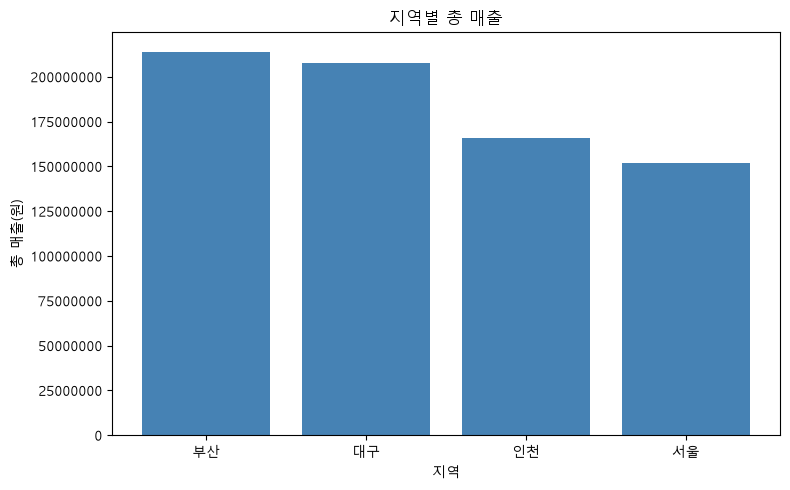

In [4]:
# images 폴더가 없으면 새로 만든다.
os.makedirs(IMAGE_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(region_totals.index, region_totals.values, color="steelblue")
ax.set_title("지역별 총 매출")
ax.set_xlabel("지역")
ax.set_ylabel("총 매출(원)")
ax.ticklabel_format(style="plain", axis="y")  # y축 숫자를 지수 표기 없이 표시

fig.tight_layout()
fig.savefig(os.path.join(IMAGE_DIR, "region_sales.png"))
plt.show()

## 2. 월별 총 매출

In [5]:
monthly_totals = calc_monthly_totals(df_month)
monthly_totals

연월
2025-01     64047000
2025-02     86237000
2025-03     12264000
2025-04     25703000
2025-05     51240000
2025-06     82376000
2025-07     66447000
2025-08     43840000
2025-09     28791000
2025-10    135369000
2025-11     44755000
2025-12     98284000
Name: 매출, dtype: int64

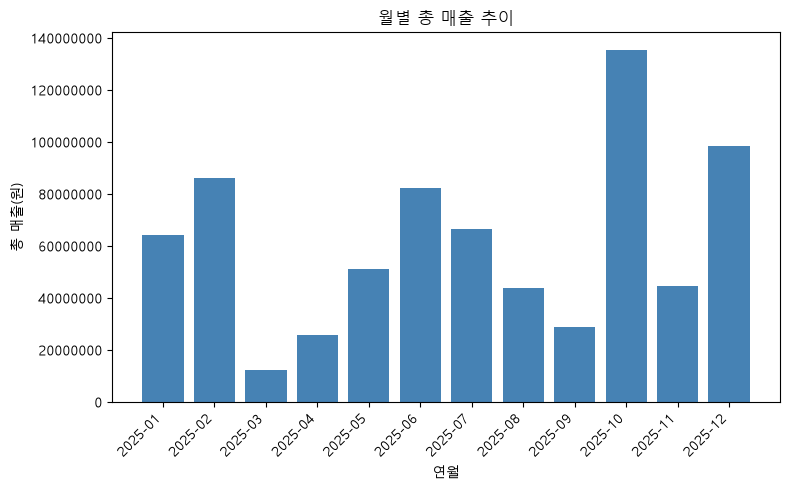

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(monthly_totals.index, monthly_totals.values, color="steelblue")
ax.set_title("월별 총 매출 추이")
ax.set_xlabel("연월")
ax.set_ylabel("총 매출(원)")
ax.ticklabel_format(style="plain", axis="y")  # y축 숫자를 지수 표기 없이 표시
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")  # 연월 라벨이 겹치지 않도록 기울임

fig.tight_layout()
fig.savefig(os.path.join(IMAGE_DIR, "monthly_sales_trend.png"))
plt.show()

## 3. 월별 x 지역별 매출

In [7]:
monthly_region_pivot = calc_monthly_region_pivot(df_month)
monthly_region_pivot

지역,서울,부산,대구,인천
연월,,,,
2025-01,14548000.0,31028000.0,14089000.0,4382000.0
2025-02,4350000.0,54109000.0,12536000.0,15242000.0
2025-03,648000.0,2050000.0,5730000.0,3836000.0
2025-04,15586000.0,9690000.0,106000.0,321000.0
2025-05,2374000.0,5018000.0,10676000.0,33172000.0
2025-06,2007000.0,16778000.0,30681000.0,32910000.0
2025-07,40986000.0,8175000.0,12343000.0,4943000.0
2025-08,7795000.0,NaN,30480000.0,5565000.0
2025-09,390000.0,25900000.0,1845000.0,656000.0


In [8]:
# reports 폴더가 없으면 새로 만든다.
os.makedirs(REPORT_DIR, exist_ok=True)

# encoding="utf-8-sig" : 엑셀에서 한글 CSV를 열 때 깨지지 않도록 하는 인코딩이다.
monthly_region_pivot.to_csv(
    os.path.join(REPORT_DIR, "monthly_region_sales.csv"), encoding="utf-8-sig"
)
print("reports/monthly_region_sales.csv 저장 완료")

reports/monthly_region_sales.csv 저장 완료


## 4. 제품별 총 매출

In [9]:
product_totals = calc_product_totals(df)
product_totals

제품
노트북    562396000
모니터    149022000
키보드     17927000
마우스     10008000
Name: 매출, dtype: int64

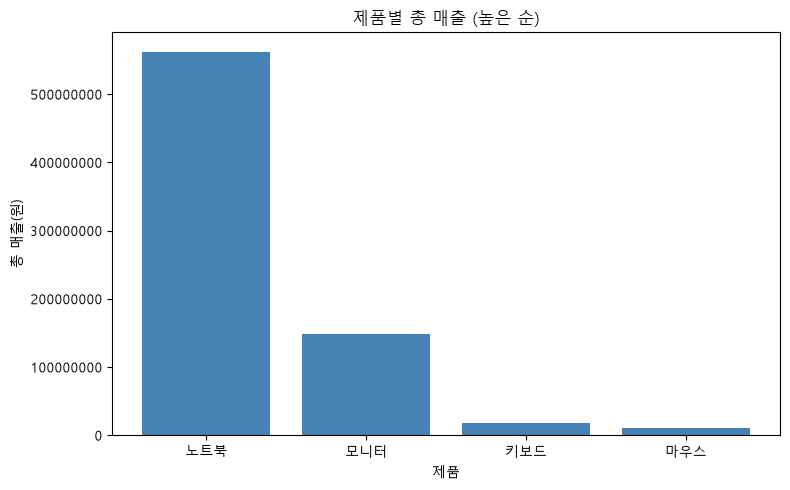

In [10]:
# product_totals는 이미 매출 내림차순으로 정렬되어 있으므로,
# index(제품명) 순서 그대로 막대그래프를 그리면 매출 높은 순으로 표시된다.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(product_totals.index, product_totals.values, color="steelblue")
ax.set_title("제품별 총 매출 (높은 순)")
ax.set_xlabel("제품")
ax.set_ylabel("총 매출(원)")
ax.ticklabel_format(style="plain", axis="y")  # y축 숫자를 지수 표기 없이 표시

fig.tight_layout()
fig.savefig(os.path.join(IMAGE_DIR, "product_sales.png"))
plt.show()

## 5. 지역 x 제품 교차 매출

지역마다 어떤 제품이 잘 팔리는지 한눈에 비교하기 위한 신규 분석이다.

In [11]:
region_product_pivot = calc_region_product_pivot(df)
region_product_pivot

제품,노트북,마우스,모니터,키보드
지역,,,,
서울,126870000,2028000,19572000,3466000
부산,155472000,1665000,52296000,4628000
대구,155205000,2492000,44633000,5277000
인천,124849000,3823000,32521000,4556000


In [12]:
region_product_pivot.to_csv(
    os.path.join(REPORT_DIR, "region_product_sales.csv"), encoding="utf-8-sig"
)
print("reports/region_product_sales.csv 저장 완료")

reports/region_product_sales.csv 저장 완료


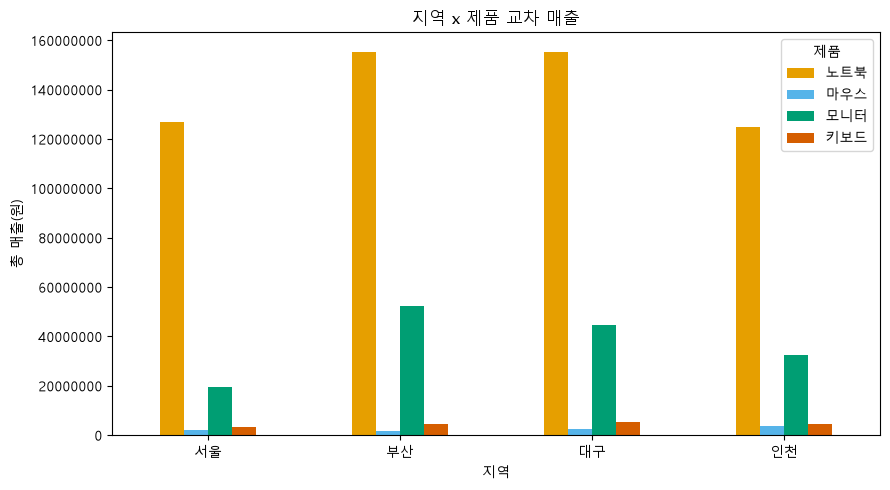

In [13]:
# 지역마다 4개 제품(노트북/마우스/모니터/키보드) 막대를 나란히 그리는 그룹 막대그래프다.
# 제품마다 다른 색을 써야 범례로 구분할 수 있으므로, 색맹인 사람도 구분하기 쉬운
# Okabe-Ito 배색(주황/하늘색/청록/주홍)을 region_product_pivot의 컬럼 순서에 맞춰 지정한다.
PRODUCT_COLORS = {
    "노트북": "#E69F00",  # 주황
    "마우스": "#56B4E9",  # 하늘색
    "모니터": "#009E73",  # 청록
    "키보드": "#D55E00",  # 주홍
}
colors = [PRODUCT_COLORS[product] for product in region_product_pivot.columns]

# DataFrame.plot(kind="bar")를 쓰면 컬럼(제품)별로 자동으로 그룹 막대그래프를 그려준다.
ax = region_product_pivot.plot(
    kind="bar", figsize=(9, 5), color=colors, rot=0
)
ax.set_title("지역 x 제품 교차 매출")
ax.set_xlabel("지역")
ax.set_ylabel("총 매출(원)")
ax.ticklabel_format(style="plain", axis="y")  # y축 숫자를 지수 표기 없이 표시
ax.legend(title="제품")

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(os.path.join(IMAGE_DIR, "region_product_sales.png"))
plt.show()

## 6. 지역별 베스트셀러 제품

지역마다 가장 많이 팔린(매출이 가장 큰) 제품 1위를 확인한다.

In [14]:
region_bestseller = calc_region_bestseller(df)
region_bestseller

,베스트셀러 제품,매출
지역,,
서울,노트북,126870000
부산,노트북,155472000
대구,노트북,155205000
인천,노트북,124849000


In [15]:
region_bestseller.to_csv(
    os.path.join(REPORT_DIR, "region_bestseller.csv"), encoding="utf-8-sig"
)
print("reports/region_bestseller.csv 저장 완료")

reports/region_bestseller.csv 저장 완료


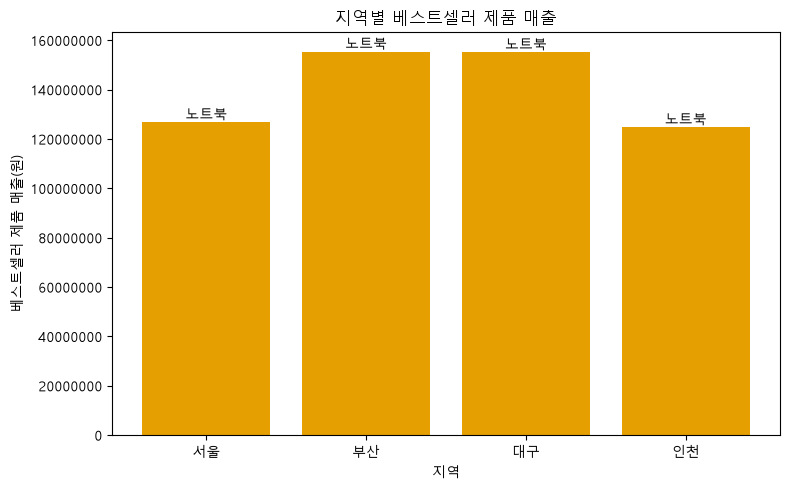

In [16]:
# 지역별 베스트셀러 제품의 매출을 막대그래프로 그린다.
# 막대 색은 위에서 정의한 PRODUCT_COLORS를 그대로 재사용해서, 어떤 제품이 1위인지
# 색으로도 바로 알아볼 수 있게 한다.
bar_colors = [PRODUCT_COLORS[product] for product in region_bestseller["베스트셀러 제품"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(region_bestseller.index, region_bestseller["매출"], color=bar_colors)
ax.set_title("지역별 베스트셀러 제품 매출")
ax.set_xlabel("지역")
ax.set_ylabel("베스트셀러 제품 매출(원)")
ax.ticklabel_format(style="plain", axis="y")  # y축 숫자를 지수 표기 없이 표시

# 막대 위에 어떤 제품이 1위인지 직접 글자로 표시한다 (색만으로는 헷갈릴 수 있으므로).
for i, 매출액 in enumerate(region_bestseller["매출"]):
    제품명 = region_bestseller["베스트셀러 제품"].iloc[i]
    ax.text(i, 매출액, 제품명, ha="center", va="bottom")

fig.tight_layout()
fig.savefig(os.path.join(IMAGE_DIR, "region_bestseller.png"))
plt.show()

## 7. 분기별 매출 추이

1분기~4분기의 매출 흐름을 확인한다.

In [17]:
# 분기 분석에 필요한 '분기' 컬럼을 추가한 버전을 미리 만들어둔다.
df_quarter = add_quarter_column(df)

quarterly_totals = calc_quarterly_totals(df_quarter)
quarterly_totals

분기
1    162548000
2    159319000
3    139078000
4    278408000
Name: 매출, dtype: int64

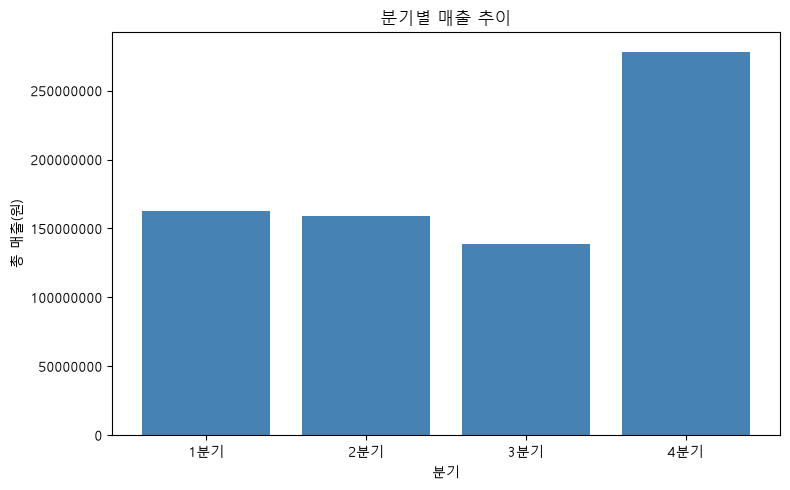

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(quarterly_totals.index, quarterly_totals.values, color="steelblue")
ax.set_title("분기별 매출 추이")
ax.set_xlabel("분기")
ax.set_ylabel("총 매출(원)")
# x축 눈금을 "1분기", "2분기"... 처럼 보기 좋게 바꾼다.
ax.set_xticks(quarterly_totals.index)
ax.set_xticklabels([f"{q}분기" for q in quarterly_totals.index])
ax.ticklabel_format(style="plain", axis="y")  # y축 숫자를 지수 표기 없이 표시

fig.tight_layout()
fig.savefig(os.path.join(IMAGE_DIR, "quarterly_sales_trend.png"))
plt.show()

In [19]:
quarterly_totals.to_csv(
    os.path.join(REPORT_DIR, "quarterly_sales.csv"), encoding="utf-8-sig"
)
print("reports/quarterly_sales.csv 저장 완료")

reports/quarterly_sales.csv 저장 완료


## 8. 파레토 분석 (상위 20% 제품이 전체 매출의 몇 %를 차지하는가)

제품을 매출이 큰 순서로 나열했을 때, 상위 20%의 제품이 전체 매출 중 얼마를 차지하는지 확인한다.
비중이 크다면 그 제품들을 할인 대상에서 신중히 고려하거나(핵심 매출원 보호),
반대로 하위권 제품들을 프로모션 대상으로 검토해볼 수 있다.

In [20]:
# calc_pareto_analysis는 이미 매출 내림차순으로 정렬된 product_totals를 입력으로 받는다.
pareto = calc_pareto_analysis(product_totals)

상위_개수 = pareto["상위_20퍼센트_제품_개수"]
상위_비율 = pareto["상위_20퍼센트_비율"]
파레토표 = pareto["누적표"]

print(
    f"전체 {len(product_totals)}개 제품 중 상위 {상위_개수}개 제품이 "
    f"전체 매출의 {상위_비율:.1f}%를 차지한다."
)
파레토표

전체 4개 제품 중 상위 1개 제품이 전체 매출의 76.1%를 차지한다.


,매출,비율(%),누적비율(%)
제품,,,
노트북,562396000,76.065966,76.065966
모니터,149022000,20.155731,96.221697
키보드,17927000,2.424688,98.646384
마우스,10008000,1.353616,100.000000


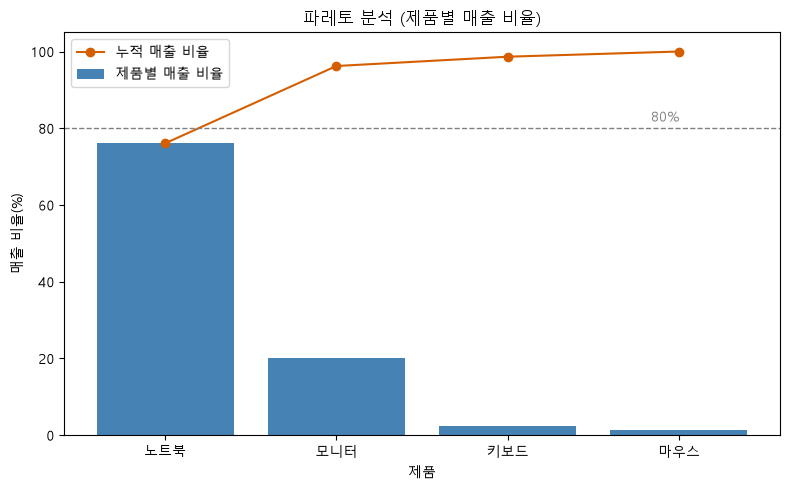

In [21]:
# 매출(원) 대신 비율(%)로 통일해서, 막대(제품별 매출 비율)와 꺾은선(누적 비율)을
# 같은 0~100% 축 하나에 그린다. (단위가 다른 두 값을 이중 축에 그리면 오독하기 쉬워서 쓰지 않는다)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(파레토표.index, 파레토표["비율(%)"], color="steelblue", label="제품별 매출 비율")
ax.plot(
    파레토표.index,
    파레토표["누적비율(%)"],
    color="#D55E00",
    marker="o",
    label="누적 매출 비율",
)

# 파레토 법칙(80/20 법칙)의 기준인 80% 지점에 점선을 그어 눈으로 비교하기 쉽게 한다.
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.text(len(파레토표) - 1, 81, "80%", color="gray", ha="right", va="bottom")

ax.set_title("파레토 분석 (제품별 매출 비율)")
ax.set_xlabel("제품")
ax.set_ylabel("매출 비율(%)")
ax.set_ylim(0, 105)
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(IMAGE_DIR, "pareto_chart.png"))
plt.show()

In [22]:
파레토표.to_csv(
    os.path.join(REPORT_DIR, "pareto_analysis.csv"), encoding="utf-8-sig"
)
print("reports/pareto_analysis.csv 저장 완료")

reports/pareto_analysis.csv 저장 완료


## 9. 데이터 검증

집계 결과들이 원본 데이터의 총매출과 일치하는지 확인한다 (완료 기준 충족 확인).

In [23]:
# 원본 데이터에서 직접 계산한 총매출 (수량 x 단가의 합)
원본_총매출 = (df["수량"] * df["단가"]).sum()

# 여러 기준(지역별/제품별/분기별)으로 나눠서 합산해도 총합은 항상 같아야 한다.
assert calc_region_totals(df).sum() == 원본_총매출, "지역별 합계가 원본과 다르다"
assert calc_product_totals(df).sum() == 원본_총매출, "제품별 합계가 원본과 다르다"
assert calc_quarterly_totals(df_quarter).sum() == 원본_총매출, "분기별 합계가 원본과 다르다"

print(f"검증 통과: 총매출 {원본_총매출:,}원 (모든 집계 기준과 일치)")

검증 통과: 총매출 739,353,000원 (모든 집계 기준과 일치)


## 저장된 파일

- `images/region_sales.png`
- `images/monthly_sales_trend.png`
- `images/product_sales.png`
- `images/region_product_sales.png`
- `images/region_bestseller.png` (신규)
- `images/quarterly_sales_trend.png` (신규)
- `images/pareto_chart.png` (신규)
- `reports/monthly_region_sales.csv`
- `reports/region_product_sales.csv`
- `reports/region_bestseller.csv` (신규)
- `reports/quarterly_sales.csv` (신규)
- `reports/pareto_analysis.csv` (신규)